In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/PHL_dataset.csv')

print(df.head())
df.info()

                  P_NAME   P_DETECTION P_DISCOVERY_FACILITY  P_YEAR  \
0  OGLE-2016-BLG-1227L b  Microlensing                 OGLE    2020   
1           Kepler-276 c       Transit               Kepler    2013   
2           Kepler-829 b       Transit               Kepler    2016   
3               K2-283 b       Transit                   K2    2018   
4           Kepler-477 b       Transit               Kepler    2016   

     P_UPDATE  P_MASS  P_MASS_ERROR_MIN  P_MASS_ERROR_MAX  P_MASS_LIMIT  \
0  2020-04-02  250.00            -120.0             413.0             0   
1  2018-09-25   16.60              -3.6               4.4             0   
2  2019-04-16    5.10               NaN               NaN             0   
3  2019-09-05   12.20               NaN               NaN             0   
4  2019-04-16    4.94               NaN               NaN             0   

      P_MASS_ORIGIN  ...  S_ABIO_ZONE  S_TIDAL_LOCK  P_HABZONE_OPT  \
0              Mass  ...          NaN      0.214133 

In [ ]:
df.shape

(5599, 118)

In [ ]:
df.columns

Index(['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE',
       'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT',
       'P_MASS_ORIGIN',
       ...
       'S_ABIO_ZONE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object', length=118)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
cols_to_keep = [

    'P_HABITABLE',
    # 'P_ESI',
    'P_RADIUS',
    'P_MASS',
    'P_GRAVITY',
    'P_ESCAPE',
    'P_PERIOD',
    'P_ECCENTRICITY',
    'P_TEMP_SURF',
    'P_TYPE_TEMP',

    'S_MASS',
    'S_RADIUS',
    'S_TEMPERATURE',
    'S_METALLICITY',
    'S_AGE',
    'S_MAG',
    'S_DISTANCE',

]


df = df[[col for col in cols_to_keep if col in df.columns]]

In [ ]:
df.shape

(5599, 16)

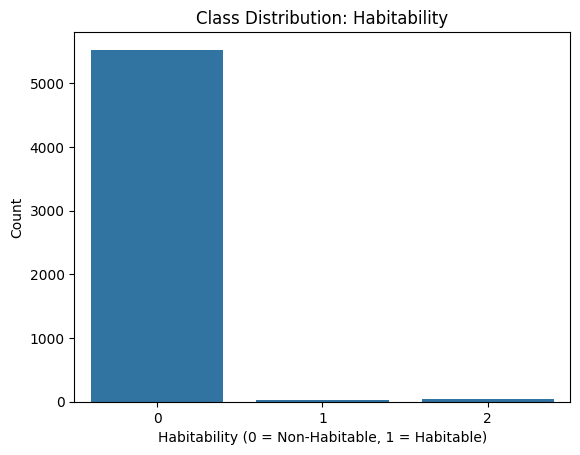

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='P_HABITABLE', data=df)
plt.title("Class Distribution: Habitability")
plt.xlabel("Habitability (0 = Non-Habitable, 1 = Habitable)")
plt.ylabel("Count")
plt.show()

In [ ]:
# Binarize the 'P_HABITABLE' column based on the logic: if 0, then 0, otherwise 1
df['P_HABITABLE'] = df['P_HABITABLE'].apply(lambda x: 0 if x == 0 else 1)

In [ ]:
df['P_HABITABLE'].value_counts()

,count
P_HABITABLE,
0,5529
1,70


Identify missing values

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = 100 * df.isnull().sum() / len(df)

missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False)

print('Columns with Missing Values :')
print(missing_df.head(30))

Columns with Missing Values :
                Missing Values  Percentage
P_TEMP_SURF               3158   56.402929
S_AGE                     1207   21.557421
P_ECCENTRICITY             777   13.877478
S_METALLICITY              433    7.733524
P_PERIOD                   249    4.447223
P_TYPE_TEMP                234    4.179318
S_RADIUS                   232    4.143597
S_MAG                      219    3.911413
S_TEMPERATURE              219    3.911413
S_DISTANCE                  21    0.375067
P_GRAVITY                    7    0.125022
P_ESCAPE                     7    0.125022
P_RADIUS                     7    0.125022
P_MASS                       7    0.125022
S_MASS                       4    0.071441


In [ ]:
df.head()

,P_HABITABLE,P_RADIUS,P_MASS,P_GRAVITY,P_ESCAPE,P_PERIOD,P_ECCENTRICITY,P_TEMP_SURF,P_TYPE_TEMP,S_MASS,S_RADIUS,S_TEMPERATURE,S_METALLICITY,S_AGE,S_MAG,S_DISTANCE
0,0,13.90,250.00,1.293929,4.240945,NaN,NaN,NaN,NaN,0.10,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2.90,16.60,1.973841,2.392517,31.884000,0.0,NaN,Hot,1.10,1.03,5779.0,0.02,0.40,15.481,1144.860
2,0,2.11,5.10,1.145527,1.554690,6.883376,0.0,1130.60440,Hot,0.98,0.97,5698.0,0.03,4.68,14.973,1073.760
3,0,3.52,12.20,0.984633,1.861695,1.921036,NaN,NaN,Hot,0.89,0.82,5060.0,0.28,NaN,14.364,402.915
4,0,2.07,4.94,1.152886,1.544822,11.119907,0.0,769.42507,Hot,0.87,0.79,5240.0,-0.04,2.09,13.835,367.000


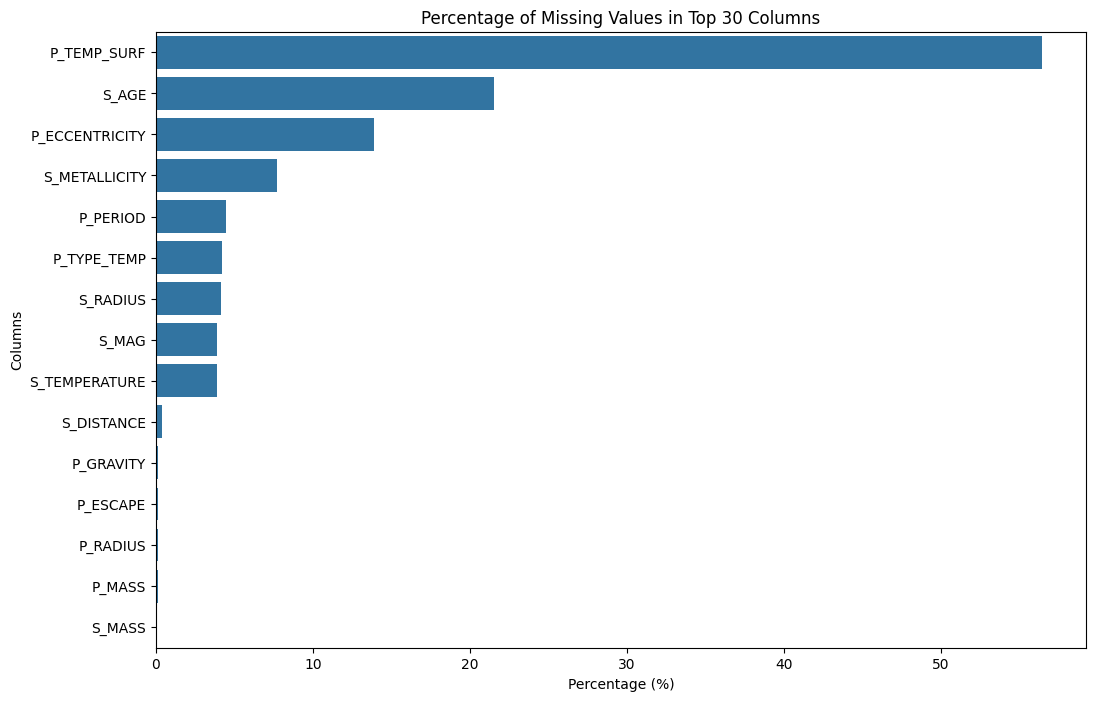

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=missing_df['Percentage'].head(30), y=missing_df.head(30).index)
plt.title('Percentage of Missing Values in Top 30 Columns')
plt.xlabel('Percentage (%)')
plt.ylabel('Columns')
plt.show()

In [ ]:
df.isnull().sum()

,0
P_HABITABLE,0
P_RADIUS,7
P_MASS,7
P_GRAVITY,7
P_ESCAPE,7
P_PERIOD,249
P_ECCENTRICITY,777
P_TEMP_SURF,3158
P_TYPE_TEMP,234
S_MASS,4


In [ ]:
df = df[df.isnull().mean(axis=1) < 0.5]


In [ ]:
df.shape

(5391, 16)

In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns

# filter out numerical columns with more than 50% missing values
numerical_cols = [col for col in numerical_cols if missing_percentage.get(col, 0) <= 50]

print(f"Number of numerical columns: {len(numerical_cols)}")
print(f"Number of suitable numerical columns (<= 50% missing values): {len(numerical_cols)}")
print("Suitable numerical columns for outlier detection:")
print(numerical_cols)

Number of numerical columns: 14
Number of suitable numerical columns (<= 50% missing values): 14
Suitable numerical columns for outlier detection:
['P_HABITABLE', 'P_RADIUS', 'P_MASS', 'P_GRAVITY', 'P_ESCAPE', 'P_PERIOD', 'P_ECCENTRICITY', 'S_MASS', 'S_RADIUS', 'S_TEMPERATURE', 'S_METALLICITY', 'S_AGE', 'S_MAG', 'S_DISTANCE']


In [ ]:
df.describe()

,P_HABITABLE,P_RADIUS,P_MASS,P_GRAVITY,P_ESCAPE,P_PERIOD,P_ECCENTRICITY,P_TEMP_SURF,S_MASS,S_RADIUS,S_TEMPERATURE,S_METALLICITY,S_AGE,S_MAG,S_DISTANCE
count,5391.000000,5387.000000,5387.000000,5387.000000,5387.000000,5.343000e+03,4822.000000,2441.000000,5389.000000,5364.000000,5374.000000,5164.000000,4389.000000,5370.000000,5374.000000
mean,0.012985,5.555878,429.975386,3.918920,3.581939,8.004212e+04,0.076407,971.994023,0.969850,1.545636,5430.585882,0.013611,4.377444,12.617960,520.532698
std,0.113218,5.293431,2396.262137,14.163411,4.637254,5.502197e+06,0.150524,487.382871,0.415253,4.198858,1778.501532,0.213445,3.085643,3.045232,518.867635
min,0.000000,0.310000,0.020000,0.038086,0.243252,9.070629e-02,0.000000,130.661650,0.010000,0.010000,415.000000,-1.000000,0.001000,0.872000,1.301190
25%,0.000000,1.750000,3.945000,1.024179,1.468607,4.460639e+00,0.000000,638.352490,0.810000,0.780000,4943.250000,-0.080000,2.340000,10.832250,107.796000
50%,0.000000,2.713000,8.400000,1.165000,1.733053,1.155102e+01,0.000000,908.701120,0.950000,0.955000,5555.000000,0.020000,3.980000,13.462000,388.815000
75%,0.000000,11.209000,133.488600,1.524769,3.463704,4.112673e+01,0.090000,1204.326300,1.100000,1.240000,5901.750000,0.120000,5.400000,15.002750,808.762000
max,1.000000,77.342000,89700.000000,387.976070,52.455064,4.020000e+08,0.950000,8125.496300,10.940000,109.460000,57000.000000,7.790000,14.900000,24.730000,8500.000000


In [ ]:
import pandas as pd

# Apply one-hot encoding to 'P_TYPE_TEMP as it has 3 unique values'
df = pd.get_dummies(df, columns=['P_TYPE_TEMP'], prefix='P_TYPE_TEMP')

print("DataFrame after one-hot encoding 'P_TYPE_TEMP':")
df.head()
df.info()

DataFrame after one-hot encoding 'P_TYPE_TEMP':
<class 'pandas.core.frame.DataFrame'>
Index: 5391 entries, 1 to 5597
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   P_HABITABLE       5391 non-null   int64  
 1   P_RADIUS          5387 non-null   float64
 2   P_MASS            5387 non-null   float64
 3   P_GRAVITY         5387 non-null   float64
 4   P_ESCAPE          5387 non-null   float64
 5   P_PERIOD          5343 non-null   float64
 6   P_ECCENTRICITY    4822 non-null   float64
 7   P_TEMP_SURF       2441 non-null   float64
 8   S_MASS            5389 non-null   float64
 9   S_RADIUS          5364 non-null   float64
 10  S_TEMPERATURE     5374 non-null   float64
 11  S_METALLICITY     5164 non-null   float64
 12  S_AGE             4389 non-null   float64
 13  S_MAG             5370 non-null   float64
 14  S_DISTANCE        5374 non-null   float64
 15  P_TYPE_TEMP_Cold  5391 non-null   bool   
 16 

In [ ]:
outliers_data = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_data[col] = outliers

print("Outliers calculated for suitable numerical columns.")
print(f"Number of columns with identified outliers: {len([col for col, data in outliers_data.items() if not data.empty])}")

Outliers calculated for suitable numerical columns.
Number of columns with identified outliers: 14


In [ ]:
for col, outliers in outliers_data.items():
    print(f"Column '{col}': {len(outliers)} outliers")

Column 'P_HABITABLE': 70 outliers
Column 'P_RADIUS': 6 outliers
Column 'P_MASS': 967 outliers
Column 'P_GRAVITY': 1088 outliers
Column 'P_ESCAPE': 743 outliers
Column 'P_PERIOD': 937 outliers
Column 'P_ECCENTRICITY': 579 outliers
Column 'S_MASS': 396 outliers
Column 'S_RADIUS': 379 outliers
Column 'S_TEMPERATURE': 270 outliers
Column 'S_METALLICITY': 201 outliers
Column 'S_AGE': 308 outliers
Column 'S_MAG': 55 outliers
Column 'S_DISTANCE': 87 outliers


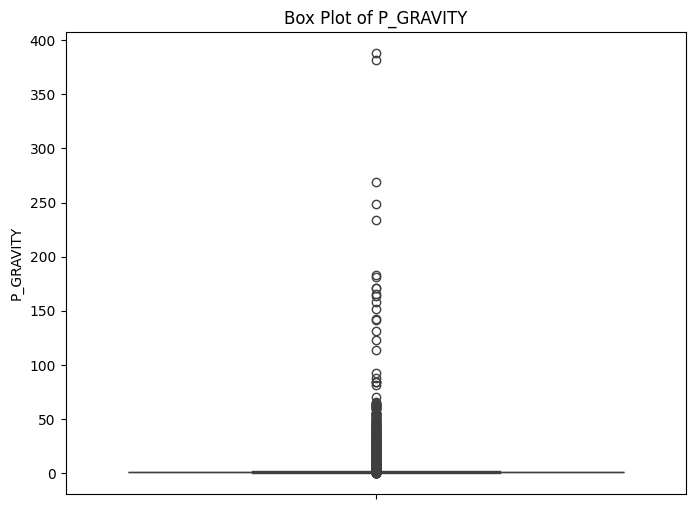

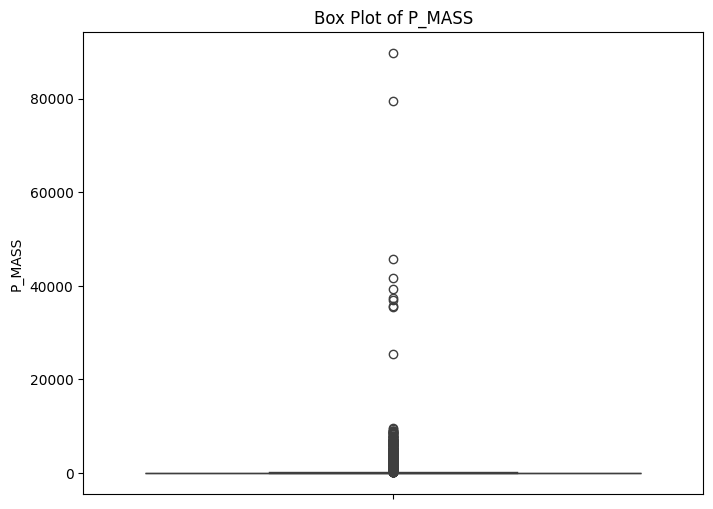

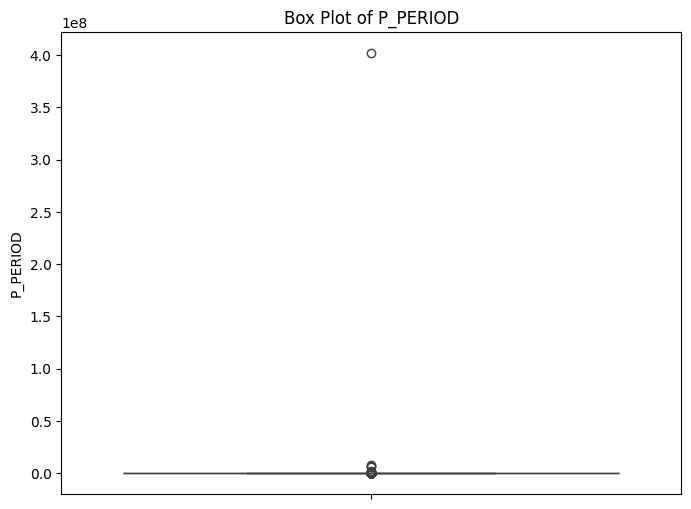

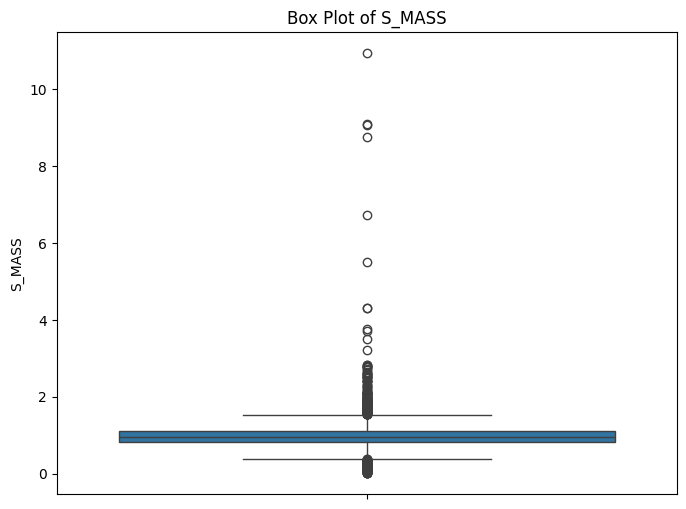

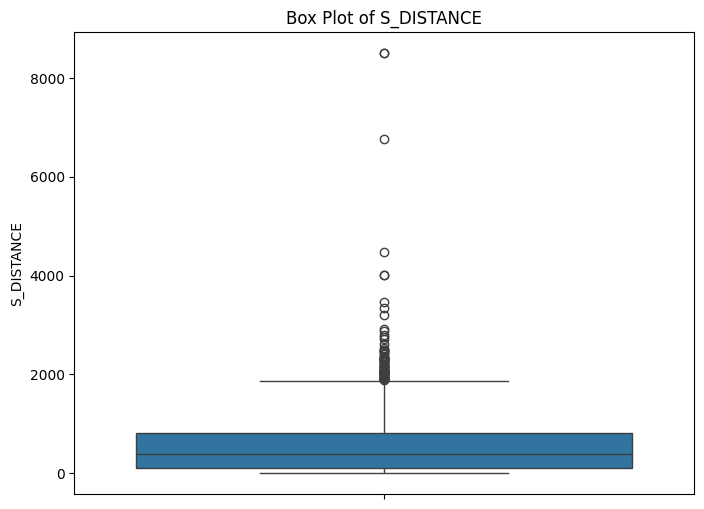

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Based on the previous outlier detection, these columns show significant outliers
key_numerical_cols = [ 'P_GRAVITY', 'P_MASS', 'P_PERIOD', 'S_MASS',  'S_DISTANCE']

for col in key_numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()


Imputing missing values

In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop(['P_HABITABLE', 'P_ESI'], errors='ignore')
cat_cols = df.select_dtypes(include=["object","bool"]).columns

# Numerical: Median Imputation
for col in num_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Categorical: Mode Imputation
for col in cat_cols:
    mode_value = df[col].mode()
    if not mode_value.empty:
        df[col] = df[col].fillna(mode_value[0])

print("Remaining missing values:\n")
print(df.isnull().sum())

Remaining missing values:

P_HABITABLE         0
P_RADIUS            0
P_MASS              0
P_GRAVITY           0
P_ESCAPE            0
P_PERIOD            0
P_ECCENTRICITY      0
P_TEMP_SURF         0
S_MASS              0
S_RADIUS            0
S_TEMPERATURE       0
S_METALLICITY       0
S_AGE               0
S_MAG               0
S_DISTANCE          0
P_TYPE_TEMP_Cold    0
P_TYPE_TEMP_Hot     0
P_TYPE_TEMP_Warm    0
dtype: int64


In [ ]:
# IQR capping
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)



In [ ]:
# # Log transform skewed features
skewed_cols = df[num_cols].skew().abs()
skewed_cols = skewed_cols[skewed_cols > 1].index

df[skewed_cols] = np.log1p(df[skewed_cols])

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separate features and targets
target_cols = ["P_HABITABLE", "P_ESI"]
feature_cols = [col for col in df.columns if col not in target_cols ]

# Select numerical features only
num_cols = df[feature_cols].select_dtypes(include=["int64", "float64"]).columns

# Apply Standard Scaling
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])



In [ ]:
df_numeric = df.select_dtypes(include=[np.number]).drop(columns=['P_TEMP_SURF'])
df_numeric.corr()

,P_HABITABLE,P_RADIUS,P_MASS,P_GRAVITY,P_ESCAPE,P_PERIOD,P_ECCENTRICITY,S_MASS,S_RADIUS,S_TEMPERATURE,S_METALLICITY,S_AGE,S_MAG,S_DISTANCE
P_HABITABLE,1.000000,-0.093349,-0.088359,-0.027863,-0.075710,0.085858,0.035482,-0.193692,-0.169200,-0.206276,-0.080690,-0.005059,0.034508,-0.087660
P_RADIUS,-0.093349,1.000000,0.962394,0.383162,0.876656,0.313043,0.476221,0.398268,0.457169,0.177089,0.214147,-0.015286,-0.497822,-0.240044
P_MASS,-0.088359,0.962394,1.000000,0.573587,0.966959,0.320434,0.498175,0.385314,0.443997,0.149569,0.213497,-0.025724,-0.508148,-0.262531
P_GRAVITY,-0.027863,0.383162,0.573587,1.000000,0.750436,0.185334,0.337080,0.202773,0.230378,0.009299,0.073398,-0.067775,-0.349812,-0.239808
P_ESCAPE,-0.075710,0.876656,0.966959,0.750436,1.000000,0.321312,0.493886,0.368106,0.422866,0.122342,0.187108,-0.049001,-0.504516,-0.273336
P_PERIOD,0.085858,0.313043,0.320434,0.185334,0.321312,1.000000,0.380517,0.165585,0.217255,0.035649,-0.045513,0.004295,-0.363863,-0.093950
P_ECCENTRICITY,0.035482,0.476221,0.498175,0.337080,0.493886,0.380517,1.000000,0.111297,0.187254,-0.082014,0.073856,0.083451,-0.595852,-0.436738
S_MASS,-0.193692,0.398268,0.385314,0.202773,0.368106,0.165585,0.111297,1.000000,0.884077,0.744147,0.230658,-0.188859,-0.360081,0.225299
S_RADIUS,-0.169200,0.457169,0.443997,0.230378,0.422866,0.217255,0.187254,0.884077,1.000000,0.593261,0.176847,-0.069472,-0.441077,0.128807
S_TEMPERATURE,-0.206276,0.177089,0.149569,0.009299,0.122342,0.035649,-0.082014,0.744147,0.593261,1.000000,0.157943,-0.143307,-0.107478,0.409303


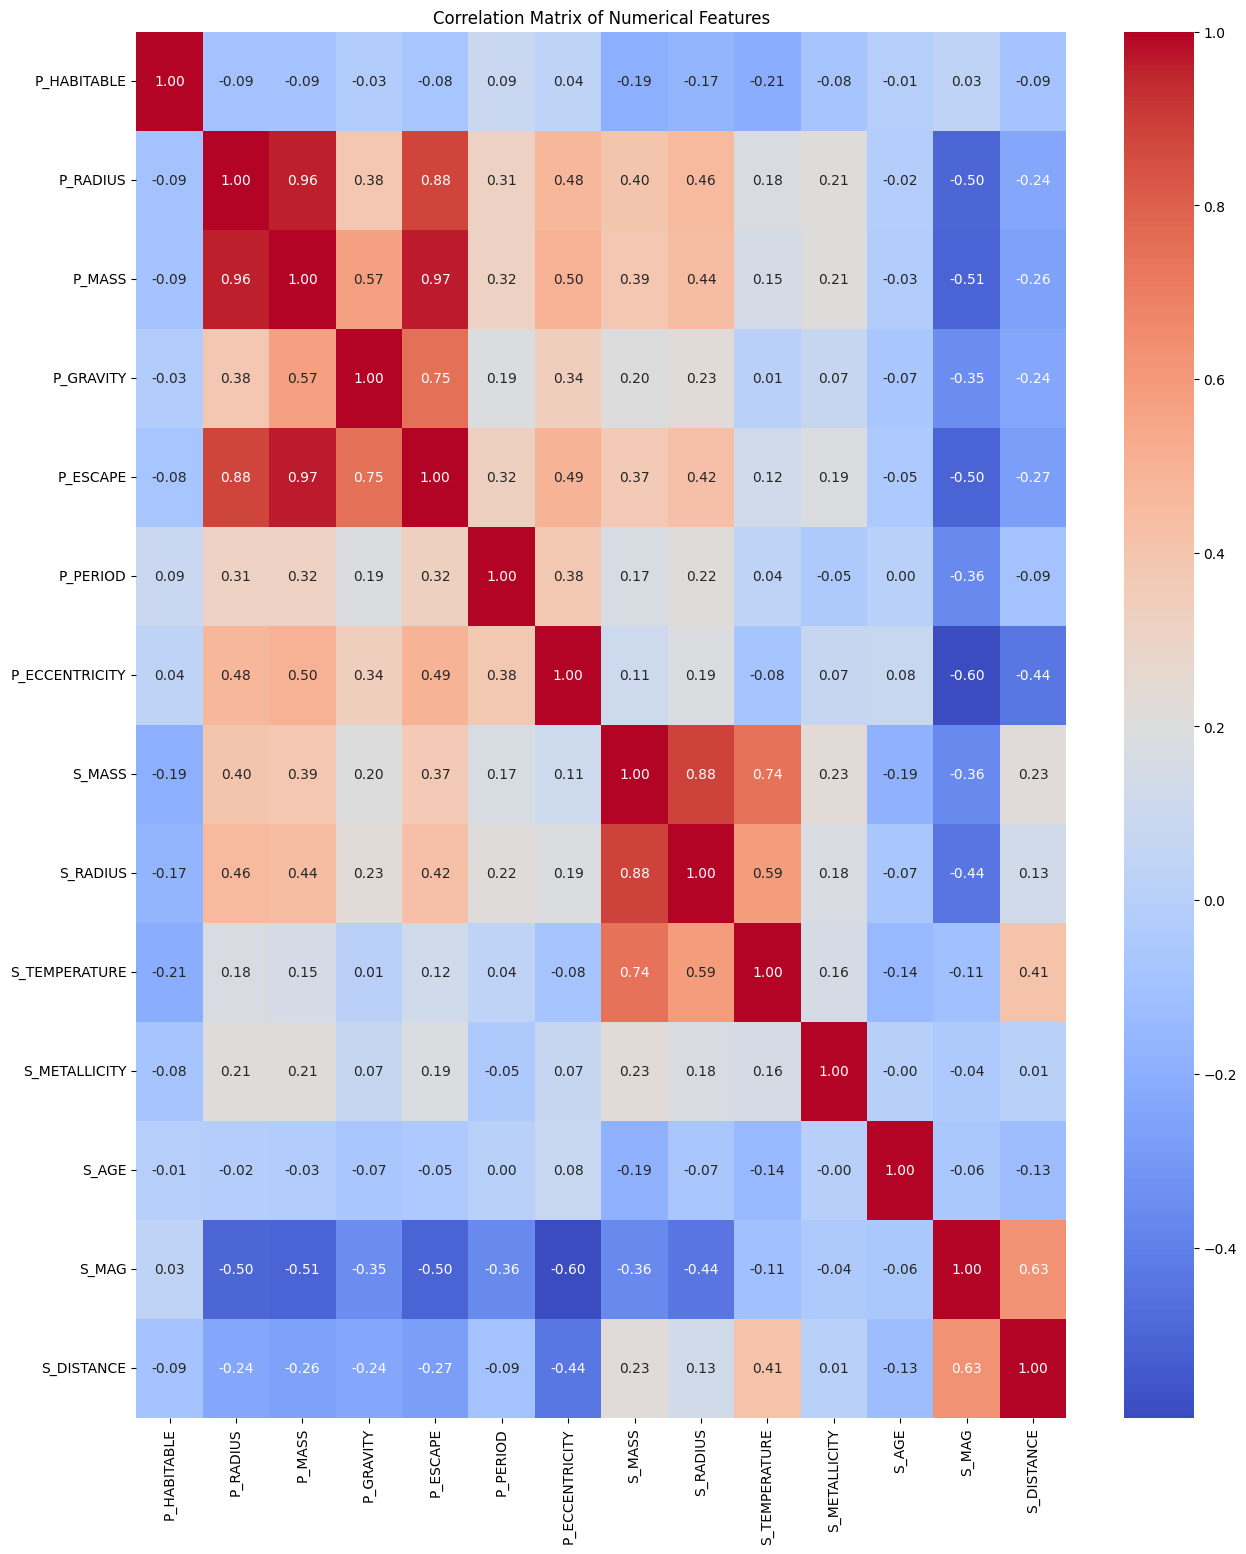

In [ ]:
plt.figure(figsize=(15, 18))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

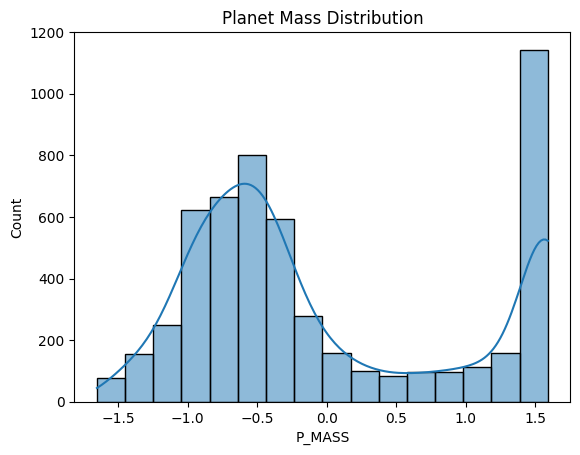

In [ ]:
sns.histplot(df['P_MASS'], kde=True)
plt.title("Planet Mass Distribution")
plt.show()


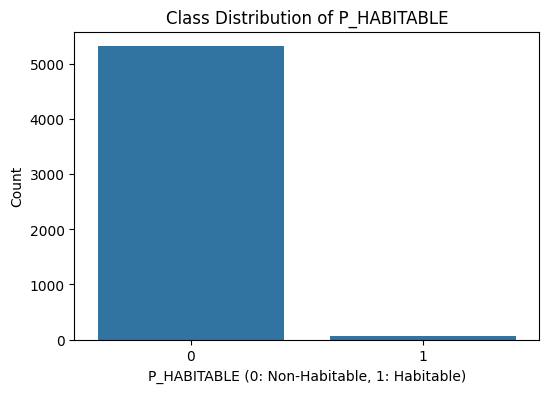

In [ ]:
y = df['P_HABITABLE']
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Class Distribution of P_HABITABLE')
plt.xlabel('P_HABITABLE (0: Non-Habitable, 1: Habitable)')
plt.ylabel('Count')
plt.show()

In [ ]:
# sns.kdeplot(df["P_ESI"], fill=True)
# plt.title("Distribution of Earth Similarity Index")
# plt.show()


In [ ]:
y = df['P_HABITABLE']
X = df.drop(columns=['P_HABITABLE'])

In [ ]:
from sklearn.decomposition import PCA
import pandas as pd

X_numeric = X.select_dtypes(include=['number'])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_numeric)

print("Explained variance ratio of PCA components:", pca.explained_variance_ratio_)


Explained variance ratio of PCA components: [0.38022294 0.19146246]


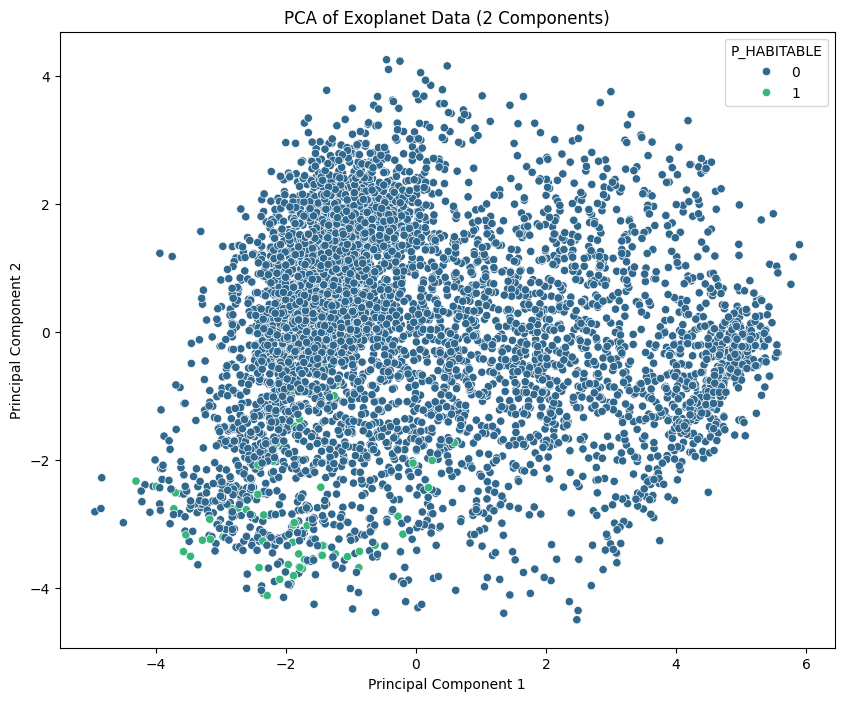

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis')
plt.title('PCA of Exoplanet Data (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='P_HABITABLE')
plt.show()

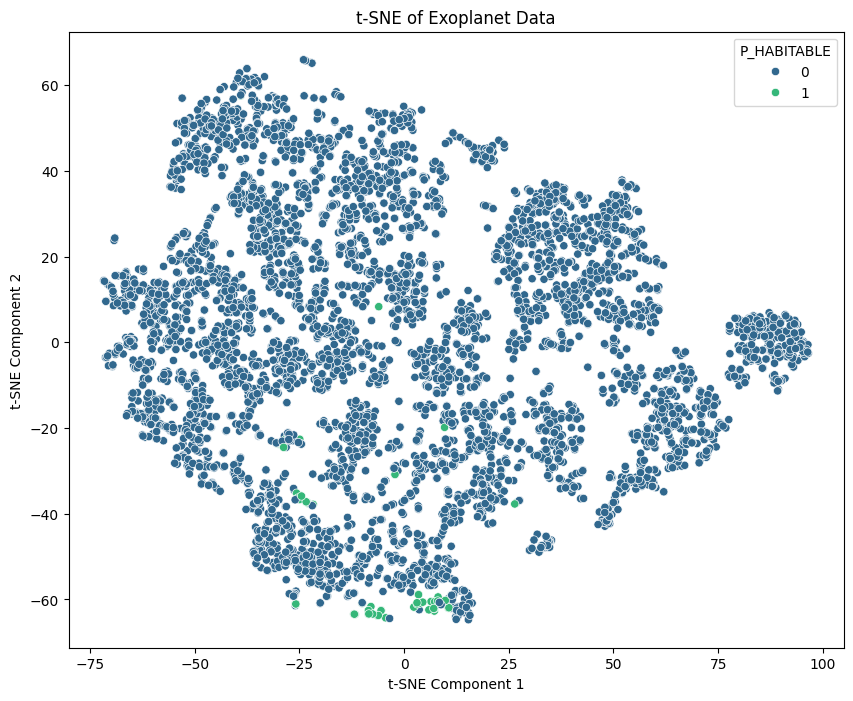

In [ ]:
from sklearn.manifold import TSNE

# t-SNE with 2 components
tsne = TSNE(n_components=2, random_state=42)

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='viridis')
plt.title('t-SNE of Exoplanet Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='P_HABITABLE')
plt.show()

Baseline model


In [ ]:
from sklearn.model_selection import train_test_split

y = df['P_HABITABLE']
X = df.drop(columns=['P_HABITABLE'])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y
)

print("Dataset split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset split into training and testing sets:
X_train shape: (4312, 16)
X_test shape: (1079, 16)
y_train shape: (4312,)
y_test shape: (1079,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error

log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel="linear",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)


SVC(class_weight='balanced', kernel='linear', probability=True, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


In [ ]:
print("Logistic Regression")
evaluate_model(log_reg, X_test, y_test)

print("\nLinear SVM")
evaluate_model(svm, X_test, y_test)

print("\nRandom Forest")
evaluate_model(rf, X_test, y_test)


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1065
           1       0.70      1.00      0.82        14

    accuracy                           0.99      1079
   macro avg       0.85      1.00      0.91      1079
weighted avg       1.00      0.99      0.99      1079

ROC-AUC: 0.9999329309188464

Linear SVM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1065
           1       0.93      1.00      0.97        14

    accuracy                           1.00      1079
   macro avg       0.97      1.00      0.98      1079
weighted avg       1.00      1.00      1.00      1079

ROC-AUC: 0.9999329309188464

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1065
           1       0.93      1.00      0.97        14

    accuracy                           1.00      1079
   macro avg       0.97  